In [2]:
# install google-play-scraper

pip install google-play-scraper pandas

Note: you may need to restart the kernel to use updated packages.


In [4]:

from google_play_scraper import app

info = app(
    'team.opay.pay',
    lang='en',
    country='ng'
)

print(info['title'])

OPay


In [6]:
# Scrap data from the internet 

from google_play_scraper import reviews, Sort
import pandas as pd

result, _ = reviews(
    'team.opay.pay',
    lang='en',
    country='ng',
    sort=Sort.NEWEST,
    count= 5000
)

print(f"Number of reviews fetched: {len(result)}")

df = pd.DataFrame(result)

print(df.head())

Number of reviews fetched: 5000
                               reviewId       userName  \
0  99df9cfe-38a9-40fe-8b33-d0e6cb2fb694  A Google user   
1  d42ebd4c-67a8-4f21-bad9-0443380b6522  A Google user   
2  2533555b-0282-4fca-a691-fe95ade036e5  A Google user   
3  f0e5ec6a-bfd4-4adf-9ac2-1d3e846e49ec  A Google user   
4  980bbb1d-be10-4211-a6e7-e70a13526883  A Google user   

                                           userImage  \
0  https://play-lh.googleusercontent.com/EGemoI2N...   
1  https://play-lh.googleusercontent.com/EGemoI2N...   
2  https://play-lh.googleusercontent.com/EGemoI2N...   
3  https://play-lh.googleusercontent.com/EGemoI2N...   
4  https://play-lh.googleusercontent.com/EGemoI2N...   

                                             content  score  thumbsUpCount  \
0  excellent job very very fast and reliable,if o...      5              0   
1                                               Nice      5              0   
2  Opay is the most fast and reliable mobile ban

In [1]:
df.to_csv("opay_reviews_raw.csv", index=False)

NameError: name 'df' is not defined

In [1]:
import os

print(os.getcwd())

C:\Users\Raifu Sodiq\jupyter


In [1]:
# Library 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from wordcloud import WordCloud, STOPWORDS

In [2]:
# import the dataset 
data = pd.read_csv("opay_reviews_raw.csv")

In [3]:
data.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,99df9cfe-38a9-40fe-8b33-d0e6cb2fb694,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"excellent job very very fast and reliable,if o...",5,0,8.9.0.465,2026-06-11 17:50:43,"Hi, @tawa nafsat. Thank you so much for the gr...",2026-06-11 18:28:43,8.9.0.465
1,d42ebd4c-67a8-4f21-bad9-0443380b6522,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Nice,5,0,8.9.0.465,2026-06-11 17:41:40,"Hi, @Lawretha Ossai. Thank you for sharing you...",2026-06-11 18:29:33,8.9.0.465
2,2533555b-0282-4fca-a691-fe95ade036e5,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Opay is the most fast and reliable mobile bank...,5,0,NaN,2026-06-11 17:40:00,"Hi, @Pawoplease. We're thrilled that you were ...",2026-06-11 18:30:33,NaN
3,f0e5ec6a-bfd4-4adf-9ac2-1d3e846e49ec,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,fast and reliable,5,0,8.9.0.465,2026-06-11 17:39:45,"Hi, @Francess. Thank you so much for the great...",2026-06-11 18:31:19,8.9.0.465
4,980bbb1d-be10-4211-a6e7-e70a13526883,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,easy to use,5,0,8.9.0.465,2026-06-11 17:37:37,"Hi, @Nimyel Nanzip. Amazing feedback 😍! We are...",2026-06-11 18:32:14,8.9.0.465


In [6]:
# print out the columns in the dataset
data.columns

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='object')

# Data Cleaning 

In [7]:
# Check duplicated 
data.duplicated().sum()

np.int64(0)

In [8]:
# Check missing number 
data.isna().sum()

reviewId                  0
userName                  0
userImage                 0
content                   0
score                     0
thumbsUpCount             0
reviewCreatedVersion    972
at                        0
replyContent              1
repliedAt                 1
appVersion              972
dtype: int64

In [9]:
# Let explore the reviweCreatedVersion and appVersion to see whelther they are the same and also to work with the missing number 
(data["reviewCreatedVersion"] == data["appVersion"]).all()

np.False_

In [10]:
(data["reviewCreatedVersion"] == data["appVersion"]).value_counts()

True     4028
False     972
Name: count, dtype: int64

In [4]:
# filling missing with most common version(mode) for each column and check if the column are the same 

data["reviewCreatedVersion"] = data["reviewCreatedVersion"].fillna(data["reviewCreatedVersion"].mode()[0])

data["appVersion"] = data["appVersion"].fillna(data["appVersion"].mode()[0])

(data["reviewCreatedVersion"] == data["appVersion"]).all()

np.True_

In [5]:
# Check missing number 
data.isna().sum()

reviewId                0
userName                0
userImage               0
content                 0
score                   0
thumbsUpCount           0
reviewCreatedVersion    0
at                      0
replyContent            1
repliedAt               1
appVersion              0
dtype: int64

In [6]:
# Drop the missing observation 

data.dropna(inplace = True)

In [21]:
data.isna().sum()

content                 0
score                   0
thumbsUpCount           0
reviewCreatedVersion    0
at                      0
repliedAt               0
label                   0
clean_content           0
dtype: int64

In [7]:
# Dropping columns that will not be useful for the project

data.drop(columns = ['reviewId', 'userName', 'userImage', 'replyContent', "appVersion" ], inplace = True)

In [8]:
# Check the first five row 
data.head()

,content,score,thumbsUpCount,reviewCreatedVersion,at,repliedAt
0,"excellent job very very fast and reliable,if o...",5,0,8.9.0.465,2026-06-11 17:50:43,2026-06-11 18:28:43
1,Nice,5,0,8.9.0.465,2026-06-11 17:41:40,2026-06-11 18:29:33
2,Opay is the most fast and reliable mobile bank...,5,0,8.7.0.454,2026-06-11 17:40:00,2026-06-11 18:30:33
3,fast and reliable,5,0,8.9.0.465,2026-06-11 17:39:45,2026-06-11 18:31:19
4,easy to use,5,0,8.9.0.465,2026-06-11 17:37:37,2026-06-11 18:32:14


In [17]:
# Covert "at" and " repliedAt" colunm to datatime 
for col in ["at", "repliedAt"]:
    data[col] = pd.to_datetime(data[col])

# EXPLORATORY DATA ANALYSIS

# Working with content column

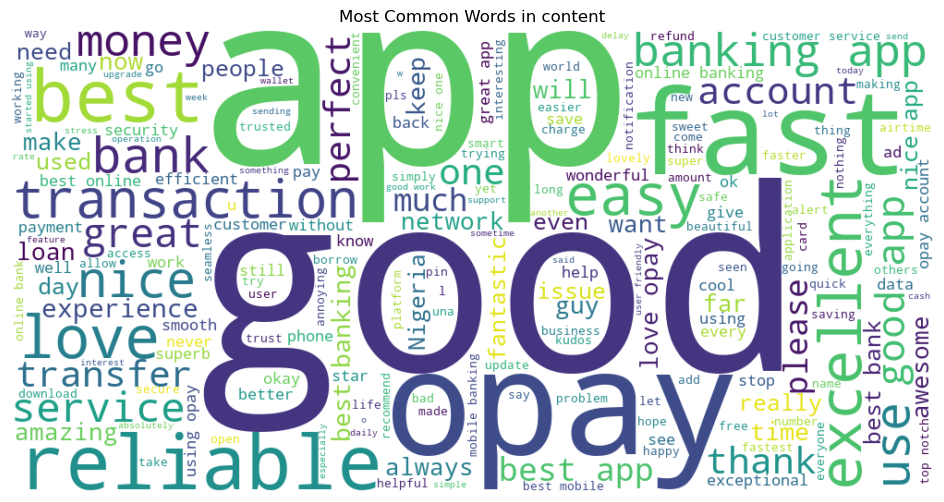

In [18]:
# Let check most common words in content 

from wordcloud import WordCloud

# Combine all content into one text
text = " ".join(data['content'].astype(str))

# Generate word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

# Display
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in content')
plt.show()


In [19]:
# Let check the length of content 
data["length"] = data["content"].str.len()

data["length"].value_counts()

length
9      432
4      369
8      202
11     176
7      173
      ... 
436      1
121      1
322      1
216      1
254      1
Name: count, Length: 316, dtype: int64

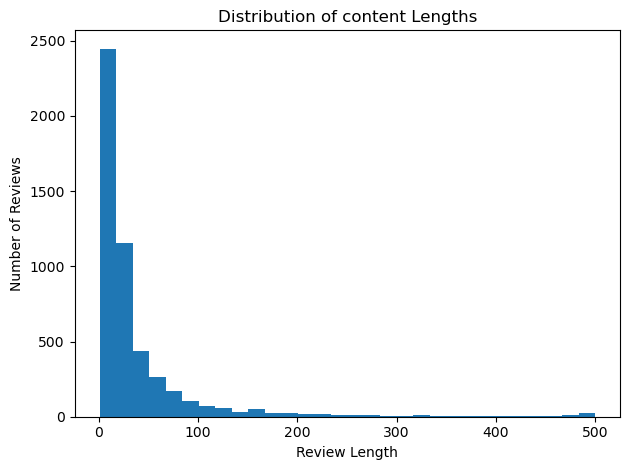

In [20]:
# plot the distribution of the length of content 
plt.hist(data["length"], bins=30)

plt.title("Distribution of content Lengths")
plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [17]:
# print the first five rows
data.head()

,content,score,thumbsUpCount,reviewCreatedVersion,at,repliedAt,length
0,"excellent job very very fast and reliable,if o...",5,0,8.9.0.465,2026-06-11 17:50:43,2026-06-11 18:28:43,86
1,Nice,5,0,8.9.0.465,2026-06-11 17:41:40,2026-06-11 18:29:33,4
2,Opay is the most fast and reliable mobile bank...,5,0,8.7.0.454,2026-06-11 17:40:00,2026-06-11 18:30:33,90
3,fast and reliable,5,0,8.9.0.465,2026-06-11 17:39:45,2026-06-11 18:31:19,17
4,easy to use,5,0,8.9.0.465,2026-06-11 17:37:37,2026-06-11 18:32:14,11


In [ ]:
# Let explore the score column 

In [18]:
# Check the number of column
data["score"].value_counts()

score
5    4066
4     357
1     327
3     141
2     109
Name: count, dtype: int64

In [19]:
# check the percentage of each column
data["score"].value_counts(normalize = True)

score
5    0.8132
4    0.0714
1    0.0654
3    0.0282
2    0.0218
Name: proportion, dtype: float64

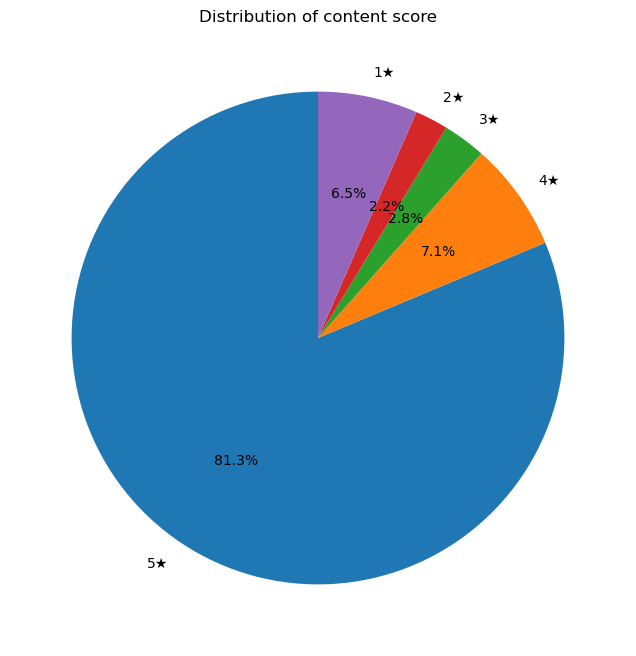

In [21]:
# plot the percentage for each score 

score_counts = data["score"].value_counts().sort_index(ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(
    score_counts,
    labels=[f"{i}★" for i in score_counts.index],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of content score")
plt.show()

# Let’s check what each score corresponds to in the content and use that to create our labels.


# First 3 content with score 5 and last 3 content with score 5

In [36]:
# The First 3 content with score 5

print("The first 3 rows of content with score 5 :\n"
      ,data[data["score"]== 5 ]["content"].head(3))

The first 3 rows of content with score 5 :
 0    excellent job very very fast and reliable,if o...
1                                                 Nice
2    Opay is the most fast and reliable mobile bank...
Name: content, dtype: object


In [37]:
# The last 3 content with score 5
print(
    "The last five reviews with score 5:\n",
    data[data["score"] == 5]["content"].tail(3))


The last five reviews with score 5:
 4997    I love you guys
4998          nice apps
4999               Good
Name: content, dtype: object


# First 3 content with score 4 and Last 3 content with score 4

In [38]:
# The first five content with score 4
print("The first 5 rows of content with score 4:\n", 
      data[data["score"]==4]["content"].head())

The first 5 rows of content with score 4:
 8                                          opay is good
19    I really loved this company, you people are am...
28    i can't save beneficiary with preferred name, ...
35                                        beautiful app
45                                             best app
Name: content, dtype: object


In [41]:
# The last 3 content with score 4

print("The last five reviews with score 4:\n",
    data[data["score"] == 4]["content"].tail(3))

The last five reviews with score 4:
 4973                                it is good and okay
4980                                    opay is good 👍🏾
4994    I have the best experience in banking with opay
Name: content, dtype: object


# First 3 content with score 3 and Last 3 content with score 3

In [39]:
# The first five content with score 3
print("The first 5 rows of content with score 3:\n", 
      data[data["score"]==3]["content"].head())

The first 5 rows of content with score 3:
 138                                                 good
171    It was very interesting at the beginning, it l...
204                            real life good money pays
211                     WA I.. lzkkiiii mm in l .k mm mm
278                                                 nice
Name: content, dtype: object


In [42]:
# The last 3 content with score 4

print("The last 3 reviews with score 3:\n",
    data[data["score"] == 3]["content"].tail(3))

The last 3 reviews with score 3:
 4909                                                 good
4910                                             Best app
4929    have trying to speak with opay superior staff ...
Name: content, dtype: object


# First 3 content with score 2 and Last 3 content with score 2

In [55]:
# The first 3 content with score 2
print("The first 3 rows of content with score 2:\n", 
      data[data["score"]==2]["content"].head(3))

The first 3 rows of content with score 2:
 39                                          thank to try
751                                       kinda good sha
756    my fingerprint payment keeps showing error mes...
Name: content, dtype: object


In [56]:
# The last 3 content with score 2

print("The last 3 reviews with score 2:\n",
    data[data["score"] == 2]["content"].tail(5))

The last 3 reviews with score 2:
 4729        very fast and smart I love and recommend opay
4815    their service is getting poor , and they getti...
4913            please my a pp was deleted I want it back
4954                  I no know why dem no dey give loans
4968    please opay bank,there is fee that is being ch...
Name: content, dtype: object


# First 3 content with score 1 and Last 3 content with score 1

In [59]:
# The first 3 content with score 1
print("The first 3 rows of content with score 1:\n", 
      data[data["score"]==1]["content"].head(3))

The first 3 rows of content with score 1:
 16                perfect 👌 👍 🥰
50    opay app has fast network
68          Not what I expected
Name: content, dtype: object


In [58]:
# The last 3 content with score 1

print("The last 3 reviews with score 2:\n",
    data[data["score"] == 1]["content"].tail(3))

The last 3 reviews with score 2:
 4940                              opay amaka
4944                                  good 👍
4963    You are widrawing stamp duty any how
Name: content, dtype: object


 # From Let the above analysis let : 
 # label score 5, 4,3 as positive (1) 
 # and score 2 and 1 as negative (0) 

In [23]:
# Creating Label
data["label"] = data["score"].apply(
    lambda x: 1 if x >= 3 else 0 )

In [22]:
data["label"].value_counts()

label
1    4563
0     436
Name: count, dtype: int64

# Let visualize most common words in postive label

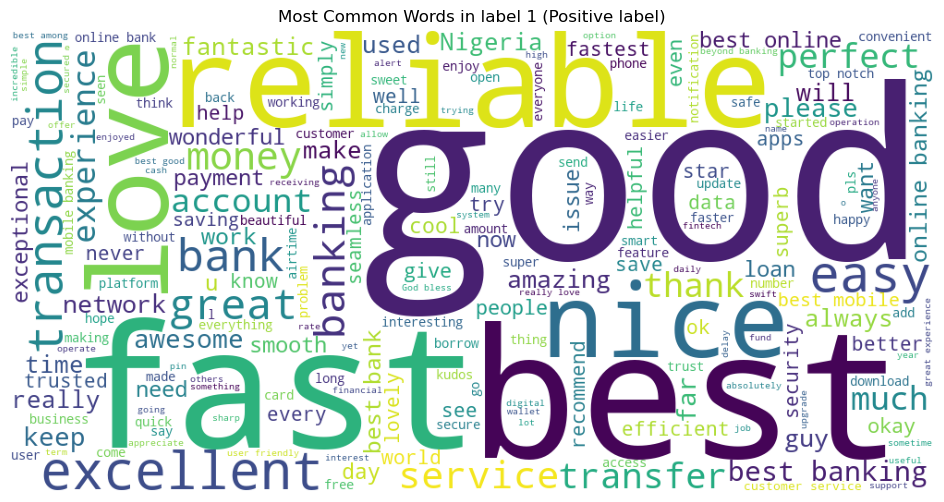

In [23]:
# Initialize common words that will be remove 
custom_stopwords = STOPWORDS.union({"app","opay","use","using","one","get", "let"})

# Combine all positive reviews into one text
positive_text = " ".join(
    data[data["label"] == 1]["content"].astype(str))

# Generate word clou
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=custom_stopwords
).generate(positive_text)

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words in label 1 (Positive label)")
plt.show()

# Let visualize most common words in negative label

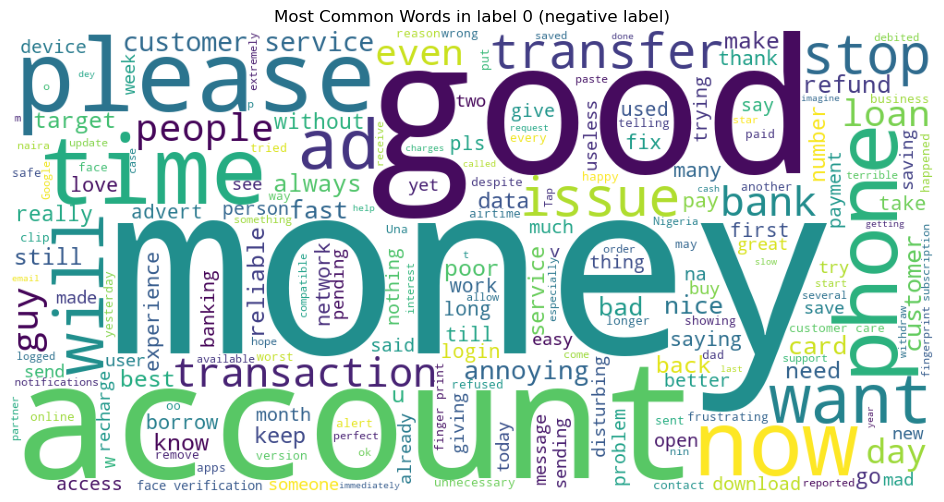

In [97]:
# Initialize common words that will be remove 
custom_stopwords = STOPWORDS.union({
    "app","opay","use","using","one","get", "let"})

# Combine all  negative contents into one text
negative_text = " ".join(
    data[data["label"] == 0]["content"].astype(str))

# Generate word clou
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=custom_stopwords
).generate(negative_text)

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words in label 0 (negative label)")
plt.show()

In [95]:
# print the first five row of the data
data.head()

,content,score,thumbsUpCount,reviewCreatedVersion,at,repliedAt,length,label
0,"excellent job very very fast and reliable,if o...",5,0,8.9.0.465,2026-06-11 17:50:43,2026-06-11 18:28:43,86,1
1,Nice,5,0,8.9.0.465,2026-06-11 17:41:40,2026-06-11 18:29:33,4,1
2,Opay is the most fast and reliable mobile bank...,5,0,8.7.0.454,2026-06-11 17:40:00,2026-06-11 18:30:33,90,1
3,fast and reliable,5,0,8.9.0.465,2026-06-11 17:39:45,2026-06-11 18:31:19,17,1
4,easy to use,5,0,8.9.0.465,2026-06-11 17:37:37,2026-06-11 18:32:14,11,1


# Working on ThumbsUpCount Variable 

In [96]:
# Checking the value count of thumbsUpCount
data["thumbsUpCount"].value_counts()

thumbsUpCount
0       4385
1        431
2         62
3         36
4         24
5         17
6         13
8         11
7          5
9          3
11         2
13         2
365        1
4437       1
74         1
201        1
25         1
26         1
624        1
448        1
10         1
Name: count, dtype: int64

In [101]:
# let check which of the label as 

data.groupby("label")["thumbsUpCount"].value_counts().reset_index()

,label,thumbsUpCount,count
0,0,0,332
1,0,1,68
2,0,2,9
3,0,3,9
4,0,4,6
5,0,5,5
6,0,8,2
7,0,6,1
8,0,7,1
9,0,13,1


# Let check the negative review that has 4437 thumbsUpCount 

In [103]:
data[data["thumbsUpCount"] ==  4437]

,content,score,thumbsUpCount,reviewCreatedVersion,at,repliedAt,length,label
4160,suddenly being disappointed. I was charged Thr...,1,4437,8.7.0.454,2026-05-18 09:07:53,2026-05-18 09:24:57,335,0


In [106]:
data[data["thumbsUpCount"] == 4437]["content"].iloc[0]

"suddenly being disappointed. I was charged Three times for one subscription for Netflix and Opay is refusing to assist me. what do they mean by consulting the merchant instead? when Netflix is ignoring me and telling to consult my bank. now I've contacted opay and I'm being snubbed, opay reply oo I'm already mad at you guys as it is😒"

# Let check the most likes("thumbsupCount") complains from the customers

In [11]:
# Most likes(thumbsupCount" complains from the customers

for _, row in data[data["label"] == 0].sort_values(
    by="thumbsUpCount",
    ascending=False
).head(10).iterrows():
    
    print(f"Likes: {row['thumbsUpCount']}")
    print(f"Score: {row['score']}")
    print(f"Review: {row['content']}")
    print(f"sent_on: {row["at"]}")
    print(f"Version of app used: {row["reviewCreatedVersion"]}")
    print("-" * 80)

Likes: 4437
Score: 1
Review: suddenly being disappointed. I was charged Three times for one subscription for Netflix and Opay is refusing to assist me. what do they mean by consulting the merchant instead? when Netflix is ignoring me and telling to consult my bank. now I've contacted opay and I'm being snubbed, opay reply oo I'm already mad at you guys as it is😒
sent_on: 2026-05-18 09:07:53
Version of app used: 8.7.0.454
--------------------------------------------------------------------------------
Likes: 624
Score: 1
Review: Allow users to disable those unsolicited & extremely annoying notifications from Opay! Update the app and include a toggle to select only the notifications users are interested in. it's not impossible to do with your current tech team if you truly consider user experience.
sent_on: 2026-06-09 15:04:33
Version of app used: 8.9.0.465
--------------------------------------------------------------------------------
Likes: 13
Score: 2
Review: you guys should implemen

In [114]:
data.head()

,content,score,thumbsUpCount,reviewCreatedVersion,at,repliedAt,length,label
0,"excellent job very very fast and reliable,if o...",5,0,8.9.0.465,2026-06-11 17:50:43,2026-06-11 18:28:43,86,1
1,Nice,5,0,8.9.0.465,2026-06-11 17:41:40,2026-06-11 18:29:33,4,1
2,Opay is the most fast and reliable mobile bank...,5,0,8.7.0.454,2026-06-11 17:40:00,2026-06-11 18:30:33,90,1
3,fast and reliable,5,0,8.9.0.465,2026-06-11 17:39:45,2026-06-11 18:31:19,17,1
4,easy to use,5,0,8.9.0.465,2026-06-11 17:37:37,2026-06-11 18:32:14,11,1


# Working with reviewCreatedVersion column

In [123]:
# Let check the value count for review_created_Version 

data["reviewCreatedVersion"].value_counts()

reviewCreatedVersion
8.7.0.454     2295
8.9.0.465     1136
8.8.2.464      311
8.5.2.451      251
8.6.0.453      242
              ... 
6.2.5.126        1
7.13.1.246       1
6.13.2.175       1
7.14.0.247       1
7.3.2.213        1
Name: count, Length: 80, dtype: int64

 # This shows that there are 80 unique version of the app
 # Let see the first 10 version of the app which of the app has 

In [154]:
review = data.groupby("reviewCreatedVersion")["label"].value_counts().reset_index()
review

,reviewCreatedVersion,label,count
0,2.16.1.250,1,1
1,4.28.1.621,0,1
2,4.39.3.51,1,1
3,5.6.3.107,1,1
4,6.0.2.116,1,1
...,...,...,...
110,8.8.0.462,0,1
111,8.8.2.464,1,283
112,8.8.2.464,0,28
113,8.9.0.465,1,1043


# Let see the first 10 version of the app that has label 1 (Positive Label)

In [146]:
label_1 = review[review["label"]==1]
label_1.sort_values("count", ascending = False).head(10)

,reviewCreatedVersion,label,count
108,8.7.0.454,1,2090
114,8.9.0.465,1,1043
112,8.8.2.464,1,283
104,8.5.2.451,1,235
106,8.6.0.453,1,228
98,8.3.0.435,1,176
96,8.2.1.434,1,75
93,8.1.2.431,1,54
101,8.4.2.441,1,47
79,7.42.0.407,1,33


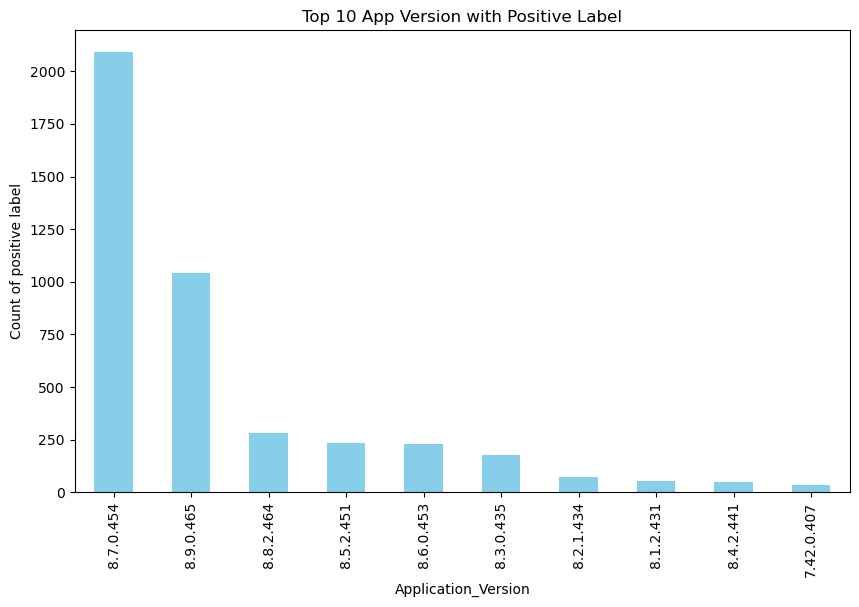

In [160]:
# Visualize the app version that has label 1 (Positive Label
label_1 = review[review["label"]==1]
label_1.sort_values("count", ascending = False).head(10).plot(kind = "bar", 
                                                              x = "reviewCreatedVersion",
                                                             y = "count",
                                                               figsize=(10,6),
                                                              color="skyblue",
                                                             legend = False)
plt.title("Top 10 App Version with Positive Label")
plt.ylabel("Count of positive label")
plt.xlabel("Application_Version")
plt.show()

 # Let see the first 10 version of the app that has label 0 (Negative Label)

In [149]:
label_0 = review[review["label"]==0]
label_0.sort_values("count", ascending = False).head(10)

,reviewCreatedVersion,label,count
107,8.7.0.454,0,205
113,8.9.0.465,0,93
111,8.8.2.464,0,28
97,8.3.0.435,0,17
103,8.5.2.451,0,16
105,8.6.0.453,0,14
92,8.1.2.431,0,11
69,7.39.4.383,0,5
95,8.2.1.434,0,5
100,8.4.2.441,0,5


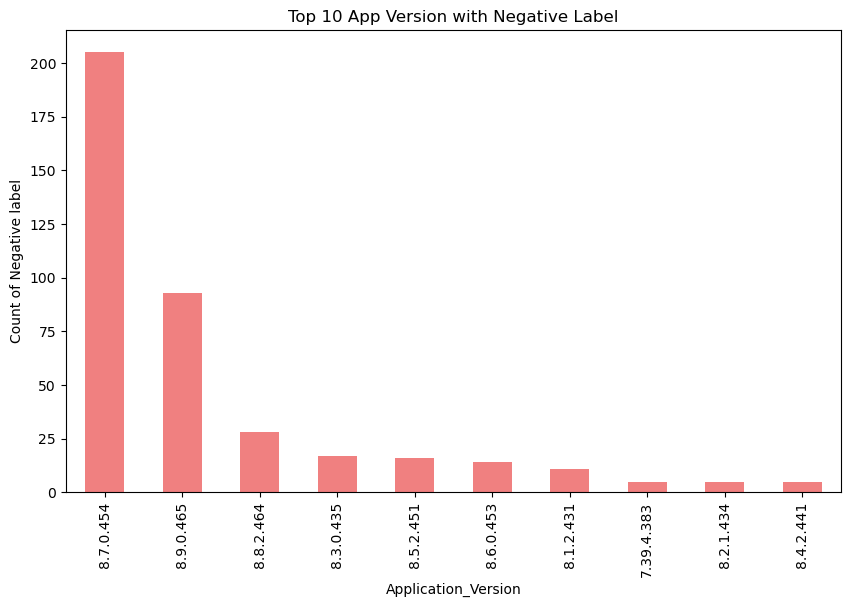

In [161]:
# Visualize the app version that has label 0 (Negative Label
label_1 = review[review["label"]==0]
label_1.sort_values("count", ascending = False).head(10).plot(kind = "bar", 
                                                              x = "reviewCreatedVersion",
                                                             y = "count",
                                                               figsize=(10,6),
                                                              color="lightcoral",
                                                             legend = False)
plt.title("Top 10 App Version with Negative Label")
plt.ylabel("Count of Negative label")
plt.xlabel("Application_Version")
plt.show()

In [133]:
data["at"].min()

Timestamp('2026-05-11 22:40:28')

In [134]:
data["at"].max()

Timestamp('2026-06-11 17:50:43')

In [22]:
data.head()

,content,score,thumbsUpCount,reviewCreatedVersion,at,repliedAt,label,clean_content
0,"excellent job very very fast and reliable,if o...",5,0,8.9.0.465,2026-06-11 17:50:43,2026-06-11 18:28:43,1,excellent job fast reliable others get network...
1,Nice,5,0,8.9.0.465,2026-06-11 17:41:40,2026-06-11 18:29:33,1,nice
2,Opay is the most fast and reliable mobile bank...,5,0,8.7.0.454,2026-06-11 17:40:00,2026-06-11 18:30:33,1,opay fast reliable mobile banking app good net...
3,fast and reliable,5,0,8.9.0.465,2026-06-11 17:39:45,2026-06-11 18:31:19,1,fast reliable
4,easy to use,5,0,8.9.0.465,2026-06-11 17:37:37,2026-06-11 18:32:14,1,easy use


# Preprocessing and Modelling 

In [12]:
# Import Library for preprocessing 
import pickle
import re                                         # Regular expressions
import string                                     # String operations and punctuation
import nltk                                       # Natural Language Toolkit
from nltk.tokenize import word_tokenize           # Tokenization  
from nltk.corpus import stopwords                 # Stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [13]:
# Load and create library

# Create lemmatizer object
lemmatizer = WordNetLemmatizer()

# Load stopwords
stop_words = set(stopwords.words("english"))

# Keep important sentiment words
sentiment_words = {"not", "no", "never"}

# Remove them from stopwords
stop_words = stop_words - sentiment_words

In [14]:
# create preprocessing function

def preprocess_text(text):
    """
    Clean, tokenize, remove stopwords,
    and lemmatize review text.
    """

    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", "", text)

    # Remove numbers and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize text
    tokens = word_tokenize(text)

    # Remove stopwords and short words
    tokens = [
        word for word in tokens
        if word not in stop_words
        and len(word) > 2
    ]

    # Lemmatize words
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    # Join tokens back into a sentence
    return " ".join(tokens)


In [15]:
# Apply to dataset
data["clean_content"] = data["content"].apply(preprocess_text)

In [16]:
# Check clean_content with original content
data[["content", "clean_content"]].head()

,content,clean_content
0,"excellent job very very fast and reliable,if o...",excellent job fast reliable others get network...
1,Nice,nice
2,Opay is the most fast and reliable mobile bank...,opay fast reliable mobile banking app good net...
3,fast and reliable,fast reliable
4,easy to use,easy use


# Features Extraction

In [17]:
# Features Extraction 
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

In [66]:
#Saving the TfidfVectorizer
pickle.dump(tfidf, open('Models/TfidfVectorize.pkl', 'wb'))

# create X_variable

In [24]:
# create X_variable 
X = tfidf.fit_transform(data["clean_content"])

# Import library for modelling 


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report, ConfusionMatrixDisplay

In [32]:
# label from the data 
y = data["label"]

In [33]:
# split the data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Using Logistics_Regression Model 

In [35]:
lr = LogisticRegression( max_iter=1000, class_weight="balanced")

In [36]:
# Fit Model 
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [38]:
# Predict on Model and print out classification report 
lr_pred = lr.predict(X_test)
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.28      0.59      0.38        87
           1       0.96      0.85      0.90       913

    accuracy                           0.83      1000
   macro avg       0.62      0.72      0.64      1000
weighted avg       0.90      0.83      0.86      1000



[[ 51  36]
 [133 780]]


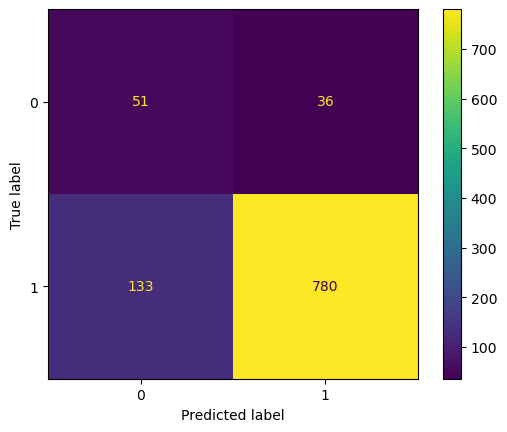

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# Testing Model with Sample Review

In [41]:
reviews = [
    "OPay is a bad app. Transactions often fail, customer support takes too long to respond, and I have experienced multiple delays when transferring money. This app has caused me a lot of frustration and I cannot recommend it to anyone.",

    "Terrible service. The app keeps crashing whenever I need to make urgent payments. My account was debited several times while transactions remained pending for hours. Very disappointing experience overall.",

    "I hate this app. The interface is confusing, the network is unreliable, and customer care rarely provides useful solutions. Every update seems to introduce new problems instead of fixing existing ones.",

    "Excellent app. Transfers are fast, the interface is easy to use, and I have had a smooth experience making payments and buying airtime. This is one of the best fintech apps I have used.",

    "By this time tomorrow I will delete this app. I am tired of failed transactions, delayed reversals, poor customer support, and constant technical issues. A financial app should be reliable, but this one has let me down too many times.",
    "Tired of this app, wahala yin ti poju",

    ]

for review in reviews:
    clean = preprocess_text(review)
    vector = tfidf.transform([clean])
    pred = lr.predict(vector)[0]

    print(f"Review: {review}")
    print(f"Prediction: {pred}")
    print("-" * 50)

Review: OPay is a bad app. Transactions often fail, customer support takes too long to respond, and I have experienced multiple delays when transferring money. This app has caused me a lot of frustration and I cannot recommend it to anyone.
Prediction: 0
--------------------------------------------------
Review: Terrible service. The app keeps crashing whenever I need to make urgent payments. My account was debited several times while transactions remained pending for hours. Very disappointing experience overall.
Prediction: 0
--------------------------------------------------
Review: I hate this app. The interface is confusing, the network is unreliable, and customer care rarely provides useful solutions. Every update seems to introduce new problems instead of fixing existing ones.
Prediction: 0
--------------------------------------------------
Review: Excellent app. Transfers are fast, the interface is easy to use, and I have had a smooth experience making payments and buying airtim

In [ ]:
# Save Model
pickle.dump(lr, open("Models/Logisticsregression.pkl","wb"))

# Using Naive Model 

In [45]:
# Instatiate Model 
nb = MultinomialNB()

# Fit Model 
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

In [46]:
# Predict on Model and print out classification report 
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.50      0.03      0.06        87
           1       0.92      1.00      0.95       913

    accuracy                           0.91      1000
   macro avg       0.71      0.52      0.51      1000
weighted avg       0.88      0.91      0.88      1000



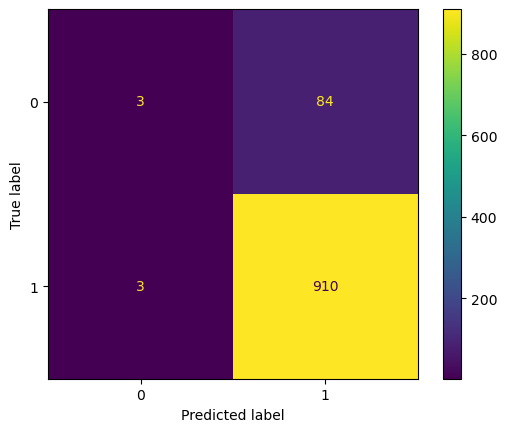

In [47]:
#Confusion Matrix
cm = confusion_matrix(y_test, nb_pred)
cm_display = ConfusionMatrixDisplay (confusion_matrix=cm, display_labels= nb.classes_)
cm_display.plot()
plt.show()

# Testing Model with Sample Review

In [48]:
reviews = [
    "OPay is a bad app. Transactions often fail, customer support takes too long to respond, and I have experienced multiple delays when transferring money. This app has caused me a lot of frustration and I cannot recommend it to anyone.",

    "Terrible service. The app keeps crashing whenever I need to make urgent payments. My account was debited several times while transactions remained pending for hours. Very disappointing experience overall.",

    "I hate this app. The interface is confusing, the network is unreliable, and customer care rarely provides useful solutions. Every update seems to introduce new problems instead of fixing existing ones.",

    "Excellent app. Transfers are fast, the interface is easy to use, and I have had a smooth experience making payments and buying airtime. This is one of the best fintech apps I have used.",

    "By this time tomorrow I will delete this app. I am tired of failed transactions, delayed reversals, poor customer support, and constant technical issues. A financial app should be reliable, but this one has let me down too many times.",
    "Tired of this app, wahala yin ti poju"
]

for review in reviews:
    clean = preprocess_text(review)
    vector = tfidf.transform([clean])
    pred = nb.predict(vector)[0]

    print(f"Review: {review}")
    print(f"Prediction: {pred}")
    print("-" * 50)

Review: OPay is a bad app. Transactions often fail, customer support takes too long to respond, and I have experienced multiple delays when transferring money. This app has caused me a lot of frustration and I cannot recommend it to anyone.
Prediction: 1
--------------------------------------------------
Review: Terrible service. The app keeps crashing whenever I need to make urgent payments. My account was debited several times while transactions remained pending for hours. Very disappointing experience overall.
Prediction: 1
--------------------------------------------------
Review: I hate this app. The interface is confusing, the network is unreliable, and customer care rarely provides useful solutions. Every update seems to introduce new problems instead of fixing existing ones.
Prediction: 1
--------------------------------------------------
Review: Excellent app. Transfers are fast, the interface is easy to use, and I have had a smooth experience making payments and buying airtim

In [49]:
# Save Model 
pickle.dump(nb, open("Models/naive.pkl","wb"))

# Using LinearSVC Model 

In [50]:
# Instantiate Model 
ls = LinearSVC( class_weight="balanced")

# fit the model 
ls.fit(X_train, y_train)

# predict with the model 
ls_pred = ls.predict(X_test)

# print classification report 
print(classification_report(y_test, ls_pred))

              precision    recall  f1-score   support

           0       0.26      0.44      0.32        87
           1       0.94      0.88      0.91       913

    accuracy                           0.84      1000
   macro avg       0.60      0.66      0.62      1000
weighted avg       0.88      0.84      0.86      1000



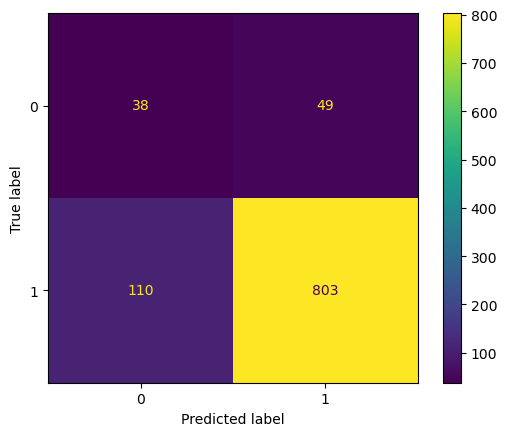

In [51]:
#Confusion Matrix
cm = confusion_matrix(y_test, ls_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels= ls.classes_)
cm_display.plot()
plt.show()

# Testing Model with Sample Review

In [52]:
reviews = [
    "OPay is a bad app. Transactions often fail, customer support takes too long to respond, and I have experienced multiple delays when transferring money. This app has caused me a lot of frustration and I cannot recommend it to anyone.",

    "Terrible service. The app keeps crashing whenever I need to make urgent payments. My account was debited several times while transactions remained pending for hours. Very disappointing experience overall.",

    "I hate this app. The interface is confusing, the network is unreliable, and customer care rarely provides useful solutions. Every update seems to introduce new problems instead of fixing existing ones.",

    "Excellent app. Transfers are fast, the interface is easy to use, and I have had a smooth experience making payments and buying airtime. This is one of the best fintech apps I have used.",

    "By this time tomorrow I will delete this app. I am tired of failed transactions, delayed reversals, poor customer support, and constant technical issues. A financial app should be reliable, but this one has let me down too many times.",
    "Tired of this app, wahala yin ti poju"
]

for review in reviews:
    clean = preprocess_text(review)
    vector = tfidf.transform([clean])
    pred = ls.predict(vector)[0]

    print(f"Review: {review}")
    print(f"Prediction: {pred}")
    print("-" * 50)

Review: OPay is a bad app. Transactions often fail, customer support takes too long to respond, and I have experienced multiple delays when transferring money. This app has caused me a lot of frustration and I cannot recommend it to anyone.
Prediction: 1
--------------------------------------------------
Review: Terrible service. The app keeps crashing whenever I need to make urgent payments. My account was debited several times while transactions remained pending for hours. Very disappointing experience overall.
Prediction: 1
--------------------------------------------------
Review: I hate this app. The interface is confusing, the network is unreliable, and customer care rarely provides useful solutions. Every update seems to introduce new problems instead of fixing existing ones.
Prediction: 1
--------------------------------------------------
Review: Excellent app. Transfers are fast, the interface is easy to use, and I have had a smooth experience making payments and buying airtim

In [53]:
# save model
pickle.dump(ls,open("Models/Linearsvc.pkl","wb"))